# 강화학습
### 기초 자율 주행 : Q-Learning기반
- 환경 : 1차선 도로
- 에이전트(차량) : 좌회전, 직진, 우회전을 하며 중앙유지를 목적으로 목표로 함

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# state(상태) - 11개의 이산적인 구간으로 나눠서 표현
state_space = np.linspace(-1.0, 1.0, 11)
print(state_space)

# 행동 구간 정의
action_space = [-1, 0, 1]
# Q[state_index, action_index]
q_table = np.zeros((len(state_space), len(action_space)))
print(q_table)

# 하이퍼 파라미터
alpha = 0.1
gammer = 0.9
epsilon = 0.9
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 500

# 현재 위치를 이산화하여 상태 인덱스로 변환 후 반환
def get_state_index(position):
  return np.argmin(np.abs(state_space - position))
print(get_state_index(-0.2), ' ',state_space[get_state_index(-0.2)])

# 보상(reward)
def get_reward(position):
  return -abs(position) # 중심을 벗어나는 모든 값들 전부 패널티 : Negative Reward
print(get_reward(0.5))

# 환경 동작 관련 정의
# 현재 위치에서 어떤 행동을 했을 때 '새로운 위치와 보상을 계산'
def stepFunc(position, action):
  position += action * 0.1
  position = np.clip(position, -1.0, 1.0)
  reward = get_reward(position) # 이동 후 보상위치 반환
  return position, reward

[-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
4   -0.19999999999999996
-0.5


In [ ]:
reward_list = []

# 학습
for ep in range(episodes):
  # 매 에피소드 마다 에이전트는 임의의 위치에서 출발
  position = np.random.uniform(-1.0, 1.0) # position의 위치를 균등분포로 줌
  total_reward = 0

  for _ in range(50):
    state_index = get_state_index(position) # q_table을 사용 할 준비

    #
    if random.random() < epsilon:
      action_idx = random.choice([0, 1, 2])
    else:
      action_idx = np.argmax(q_table[state_index])

    # 행동 선택
    action = action_space[action_idx]
    next_position , reward = stepFunc(position, action)

    # 다음 위치에 대한 이산 상태 인덱스 계산
    next_state_index = get_state_index(next_position)

    # 다음 상태 에서 선택 가능한 가장 높은 q값 - q값 갱신
    best_next_q = np.max(q_table[next_state_index])

    # Q 테이블 갱신
    q_table[state_index, action_idx] += alpha * (reward + gammer * best_next_q - q_table[state_index, action_idx])
    position = next_position
    total_reward += reward

  reward_list.append(total_reward) # 에피소드 마다 총 보상 기록
  epsilon = max(epsilon_min, epsilon * epsilon_decay)

  # 성능 지표 계산 후 출력
  if ep % 50 == 0:
    initial_avg = np.mean(reward_list[:50])
    final_avg = np.mean(reward_list[-50:])
    max_reward = np.max(reward_list)
    min_reward = np.min(reward_list)
    print('Performance Summary')
    print(f'- initial 50 episodes average reward : {initial_avg:.3f}')
    print(f'- final 50 episodes average reward : {final_avg:.3f}')
    print(f'- maximum reward : {max_reward:.3f}')
    print(f'- minimum reward : {min_reward:.3f}')

    if final_avg > initial_avg: # 개선 O
     print(f'모델이 개선 됨 (+ {(final_avg - initial_avg):.3f})\n')
    else:
      print(f'크게 개선 되지 않음\n')

Performance Summary
- initial 50 episodes average reward : -12.524
- final 50 episodes average reward : -12.524
- maximum reward : -12.524
- minimum reward : -12.524
크게 개선 되지 않음

Performance Summary
- initial 50 episodes average reward : -16.216
- final 50 episodes average reward : -16.186
- maximum reward : -4.054
- minimum reward : -42.932
모델이 개선 됨 (+ 0.029)

Performance Summary
- initial 50 episodes average reward : -16.216
- final 50 episodes average reward : -9.941
- maximum reward : -3.399
- minimum reward : -42.932
모델이 개선 됨 (+ 6.275)

Performance Summary
- initial 50 episodes average reward : -16.216
- final 50 episodes average reward : -6.833
- maximum reward : -3.313
- minimum reward : -42.932
모델이 개선 됨 (+ 9.383)

Performance Summary
- initial 50 episodes average reward : -16.216
- final 50 episodes average reward : -5.017
- maximum reward : -1.743
- minimum reward : -42.932
모델이 개선 됨 (+ 11.199)

Performance Summary
- initial 50 episodes average reward : -16.216
- final 50 episo

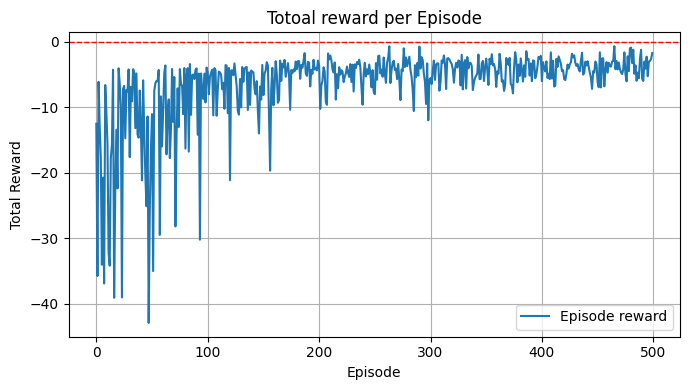

In [ ]:
from matplotlib.lines import lineStyles
# 보상 변화에 대한 시각화
plt.figure(figsize=(7, 4))
plt.plot(reward_list, label='Episode reward')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Totoal reward per Episode')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

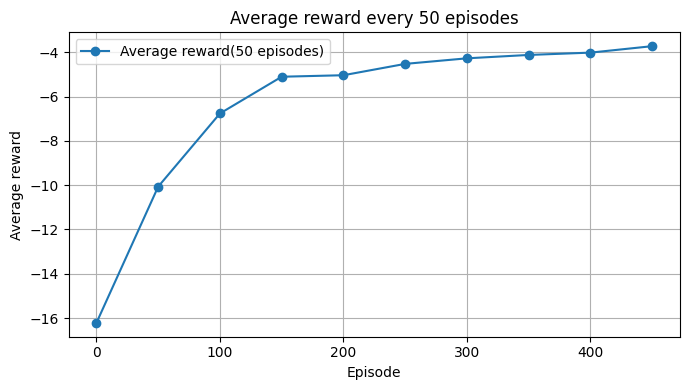

In [ ]:
# 에피소드 50개 단위로 평균 보상 시각화
window = 50 # 평균을 낼 구간 크기
avg_rewards = [] # 구간별 평균 보상 크기 저장

for i in range(0, len(reward_list), window):
  chunk = reward_list[i:i+window]
  avg = np.mean(chunk)
  avg_rewards.append(avg)

plt.figure(figsize=(7, 4))
plt.plot(range(0, len(reward_list), window), avg_rewards, marker='o', label='Average reward(50 episodes)')
plt.xlabel('Episode')
plt.ylabel('Average reward')
plt.title('Average reward every 50 episodes')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

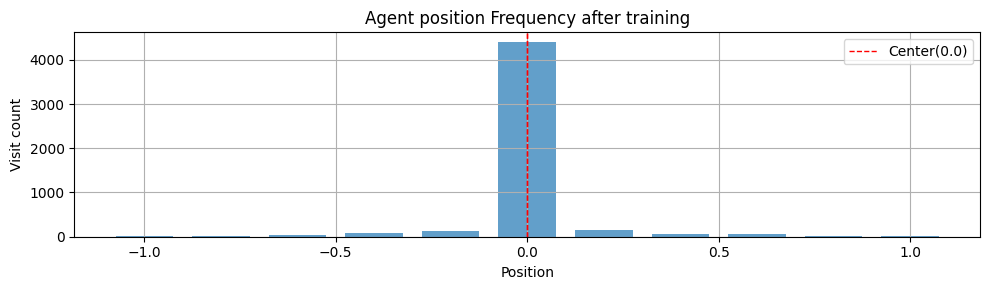

In [ ]:
# 위치 히스토그램 - 에이전트가 중앙에 얼마나 잘 머물렀는지를 확인 할 수 있다
position_count = np.zeros(len(state_space)) # 상태별 방문 수 배열 초기화

# 학습 실행하면서 위치 기록
for _ in range(100):
  position = np.random.uniform(-1.0, 1.0)
  for _ in range(50):
    state_index = get_state_index(position)
    position_count[state_index] += 1 # 해당 상태의 방문 횟수 누적

    if np.random.rand() < epsilon:
      action_idx = np.random.choice(len(action_space))
    else:
      action_idx = np.argmax(q_table[state_index])

    action = action_space[action_idx]
    position, _ = stepFunc(position, action)


plt.figure(figsize=(10, 3))
plt.bar(state_space, position_count, width=0.15, align='center', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Position')
plt.ylabel('Visit count')
plt.title('Agent position Frequency after training')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Center(0.0)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()